In [2]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [3]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

seoul_bike = fetch_ucirepo(id=560)

X = seoul_bike.data.features
y = seoul_bike.data.targets

df = pd.concat([X, y], axis=1)
df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,1/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,1/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,1/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,1/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,1/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   8760 non-null   object 
 1   Rented Bike Count      8760 non-null   int64  
 2   Hour                   8760 non-null   int64  
 3   Temperature            8760 non-null   float64
 4   Humidity               8760 non-null   int64  
 5   Wind speed             8760 non-null   float64
 6   Visibility             8760 non-null   int64  
 7   Dew point temperature  8760 non-null   float64
 8   Solar Radiation        8760 non-null   float64
 9   Rainfall               8760 non-null   float64
 10  Snowfall               8760 non-null   float64
 11  Seasons                8760 non-null   object 
 12  Holiday                8760 non-null   object 
 13  Functioning Day        8760 non-null   object 
dtypes: float64(6), int64(4), object(4)
memory usage: 958.3+ 

In [5]:
df.isnull().sum()

Date                     0
Rented Bike Count        0
Hour                     0
Temperature              0
Humidity                 0
Wind speed               0
Visibility               0
Dew point temperature    0
Solar Radiation          0
Rainfall                 0
Snowfall                 0
Seasons                  0
Holiday                  0
Functioning Day          0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df['Seasons'].unique(), df['Holiday'].unique(), df['Functioning Day'].unique()

(array(['Winter', 'Spring', 'Summer', 'Autumn'], dtype=object),
 array(['No Holiday', 'Holiday'], dtype=object),
 array(['Yes', 'No'], dtype=object))

In [8]:
df['Date'].head()

0    1/12/2017
1    1/12/2017
2    1/12/2017
3    1/12/2017
4    1/12/2017
Name: Date, dtype: object

In [9]:
df['Functioning Day'].value_counts()

Functioning Day
Yes    8465
No      295
Name: count, dtype: int64

In [10]:
df['Date'].iloc[[0, -1]]

0        1/12/2017
8759    30/11/2018
Name: Date, dtype: object

In [11]:
df = df[df['Functioning Day'] == 'Yes'].reset_index(drop=True)
df.shape

(8465, 14)

In [12]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Date'].head()

0   2017-12-01
1   2017-12-01
2   2017-12-01
3   2017-12-01
4   2017-12-01
Name: Date, dtype: datetime64[ns]

In [13]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.columns

Index(['date', 'rented_bike_count', 'hour', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'dew_point_temperature', 'solar_radiation',
       'rainfall', 'snowfall', 'seasons', 'holiday', 'functioning_day'],
      dtype='object')

In [14]:
# ## Data Cleaning

# Initial dataset: 8760 rows, 14 columns.

# Steps performed:
# - Removed 295 rows where Functioning Day = 'No' (system was offline, 
#   target trivially 0 — not a real demand signal)
# - Converted Date from text to datetime format (day/month/year)
# - Renamed columns to snake_case for consistency
# - No missing values or duplicates found in the raw dataset

# Final dataset: 8465 rows, 14 columns.

In [15]:
df['rented_bike_count'].describe()

count    8465.000000
mean      729.156999
std       642.351166
min         2.000000
25%       214.000000
50%       542.000000
75%      1084.000000
max      3556.000000
Name: rented_bike_count, dtype: float64

<Axes: >

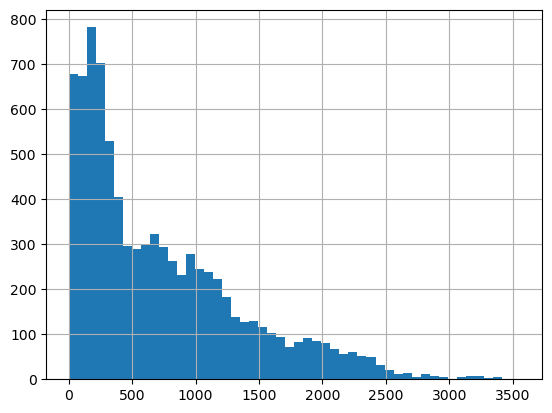

In [16]:
df['rented_bike_count'].hist(bins=50)

In [33]:
import numpy as np
counts, bin_edges = np.histogram(df['rented_bike_count'], bins=10)
list(zip(bin_edges.astype(int), counts))

[(2, 3366),
 (357, 1610),
 (712, 1310),
 (1068, 908),
 (1423, 512),
 (1779, 408),
 (2134, 248),
 (2489, 61),
 (2845, 26),
 (3200, 16)]

<Axes: xlabel='hour'>

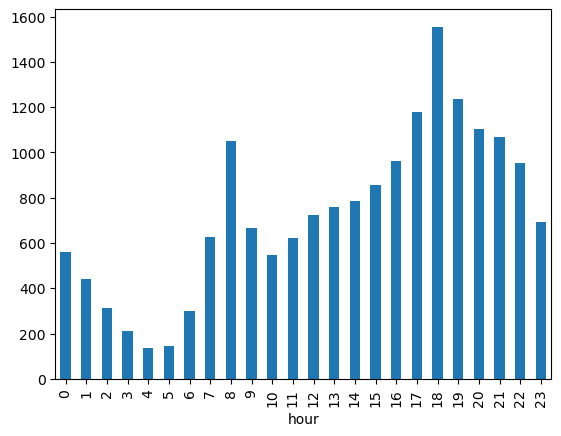

In [28]:
df.groupby('hour')['rented_bike_count'].mean().plot(kind='bar')

<Axes: xlabel='seasons'>

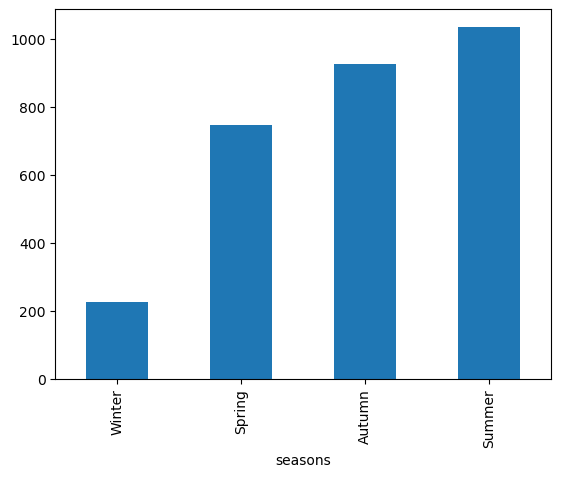

In [18]:
df.groupby('seasons')['rented_bike_count'].mean().sort_values().plot(kind='bar')

<Axes: xlabel='temperature', ylabel='rented_bike_count'>

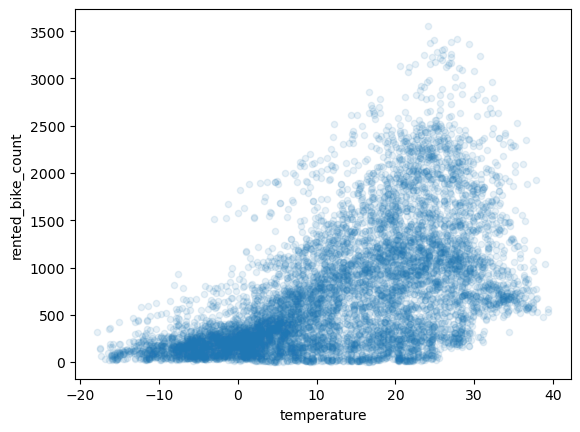

In [19]:
df.plot(kind='scatter', x='temperature', y='rented_bike_count', alpha=0.1)

In [20]:
df.groupby('rainfall')['rented_bike_count'].mean()

rainfall
0.0     765.632029
0.1     344.977273
0.2     185.300000
0.3     155.666667
0.4     134.187500
           ...    
21.0     19.000000
21.5    596.000000
24.0     61.000000
29.5    122.000000
35.0    151.000000
Name: rented_bike_count, Length: 61, dtype: float64

In [30]:
df['day_of_week'] = df['date'].dt.day_name()
df.groupby(['day_of_week', 'hour'])['rented_bike_count'].mean().unstack(level=0)

day_of_week,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
hour,,,,,,,
0,549.882353,459.576923,690.100000,651.372549,540.86,512.916667,526.06
1,448.607843,296.173077,621.060000,475.960784,431.38,412.083333,412.02
2,298.392157,199.865385,456.560000,365.490196,301.04,282.041667,288.52
3,200.372549,132.769231,311.780000,256.235294,191.68,184.937500,199.50
4,130.431373,103.153846,192.220000,157.078431,123.70,124.687500,131.76
5,153.372549,157.423077,144.400000,106.862745,148.02,152.479167,147.34
6,360.019608,370.346154,194.040000,134.000000,333.96,362.687500,333.98
7,783.568627,797.480769,300.921569,209.254902,733.20,817.791667,756.56
8,1337.960784,1268.903846,496.666667,344.921569,1244.40,1382.666667,1300.06


<Axes: xlabel='hour'>

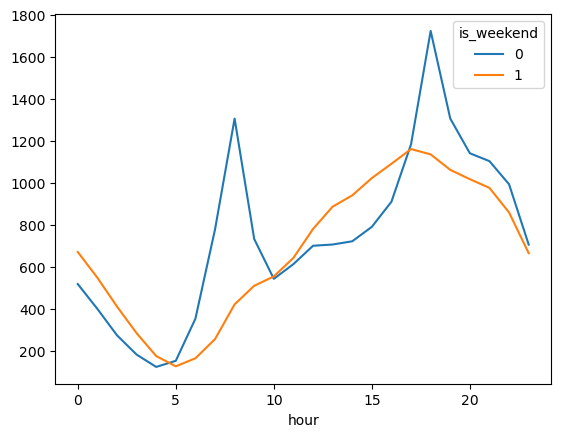

In [32]:
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
df.groupby(['is_weekend', 'hour'])['rented_bike_count'].mean().unstack(level=0).plot()

In [22]:
df['rain_category'] = pd.cut(df['rainfall'], bins=[-0.1, 0, 2.5, 7.6, 100], labels=['none', 'light', 'moderate', 'heavy'])
df.groupby('rain_category')['rented_bike_count'].mean()

/tmp/ipykernel_93/1141651056.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('rain_category')['rented_bike_count'].mean()


rain_category
none        765.632029
light       190.306122
moderate    107.724138
heavy        63.054054
Name: rented_bike_count, dtype: float64

In [24]:
df.select_dtypes(include='number').corr()['rented_bike_count'].sort_values()

humidity                -0.201973
snowfall                -0.151611
rainfall                -0.128626
is_weekend              -0.046360
wind_speed               0.125022
visibility               0.212323
solar_radiation          0.273862
dew_point_temperature    0.400263
hour                     0.425256
temperature              0.562740
rented_bike_count        1.000000
Name: rented_bike_count, dtype: float64

In [34]:
df.groupby('seasons').apply(lambda x: x['snowfall'].corr(x['rented_bike_count']))

/opt/conda/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_93/2915653415.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('seasons').apply(lambda x: x['snowfall'].corr(x['rented_bike_count']))


seasons
Autumn   -0.126091
Spring         NaN
Summer         NaN
Winter   -0.185811
dtype: float64

In [35]:
# ## Exploratory Data Analysis

# Target (rented_bike_count) is right-skewed: most hours 0-500, long tail up to 3556.

# Time patterns:
# - Weekdays: sharp commute peaks at 8:00 and 18:00
# - Weekends: no morning peak, demand spread evenly across midday/afternoon
# - is_weekend has near-zero linear correlation (-0.05) but changes the shape 
#   of the hourly pattern, not the average — kept as a feature despite low correlation

# Weather patterns:
# - temperature has the strongest correlation with demand (0.56)
# - dew_point_temperature (0.40) likely collinear with temperature — check before linear models
# - rainfall sharply reduces demand even at light levels (765 -> 190 avg count)
# - humidity, snowfall, rainfall: weak negative correlation overall
# - snowfall correlation persists within Autumn (-0.13) and Winter (-0.19) alone,
#   so the effect is not just a byproduct of winter having low demand overall
# - wind_speed: negligible correlation

# Seasonality: summer highest demand, winter lowest

# New feature created: is_weekend (0/1)

In [36]:
import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df[['hour', 'hour_sin', 'hour_cos']].head(10)

,hour,hour_sin,hour_cos
0,0,0.000000,1.000000e+00
1,1,0.258819,9.659258e-01
2,2,0.500000,8.660254e-01
3,3,0.707107,7.071068e-01
4,4,0.866025,5.000000e-01
5,5,0.965926,2.588190e-01
6,6,1.000000,6.123234e-17
7,7,0.965926,-2.588190e-01
8,8,0.866025,-5.000000e-01
9,9,0.707107,-7.071068e-01


In [37]:
df = pd.get_dummies(df, columns=['seasons', 'holiday'], drop_first=True)
df.head()

,date,rented_bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temperature,solar_radiation,rainfall,...,functioning_day,day_of_week,rain_category,is_weekend,hour_sin,hour_cos,seasons_Spring,seasons_Summer,seasons_Winter,holiday_No Holiday
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,...,Yes,Friday,none,0,0.000000,1.000000,False,False,True,True
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,...,Yes,Friday,none,0,0.258819,0.965926,False,False,True,True
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,...,Yes,Friday,none,0,0.500000,0.866025,False,False,True,True
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,...,Yes,Friday,none,0,0.707107,0.707107,False,False,True,True
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,...,Yes,Friday,none,0,0.866025,0.500000,False,False,True,True


In [38]:
df = df.drop(columns=['functioning_day', 'rain_category', 'hour', 'day_of_week'])
df.head()

,date,rented_bike_count,temperature,humidity,wind_speed,visibility,dew_point_temperature,solar_radiation,rainfall,snowfall,is_weekend,hour_sin,hour_cos,seasons_Spring,seasons_Summer,seasons_Winter,holiday_No Holiday
0,2017-12-01,254,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,0,0.000000,1.000000,False,False,True,True
1,2017-12-01,204,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,0,0.258819,0.965926,False,False,True,True
2,2017-12-01,173,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,0,0.500000,0.866025,False,False,True,True
3,2017-12-01,107,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,0,0.707107,0.707107,False,False,True,True
4,2017-12-01,78,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,0,0.866025,0.500000,False,False,True,True


In [39]:
df[['temperature', 'dew_point_temperature']].corr()

,temperature,dew_point_temperature
temperature,1.000000,0.914467
dew_point_temperature,0.914467,1.000000


In [42]:
# df = df.drop(columns=['dew_point_temperature'])
df.head()

,date,rented_bike_count,temperature,humidity,wind_speed,visibility,solar_radiation,rainfall,snowfall,is_weekend,hour_sin,hour_cos,seasons_Spring,seasons_Summer,seasons_Winter,holiday_No Holiday
0,2017-12-01,254,-5.2,37,2.2,2000,0.0,0.0,0.0,0,0.000000,1.000000,False,False,True,True
1,2017-12-01,204,-5.5,38,0.8,2000,0.0,0.0,0.0,0,0.258819,0.965926,False,False,True,True
2,2017-12-01,173,-6.0,39,1.0,2000,0.0,0.0,0.0,0,0.500000,0.866025,False,False,True,True
3,2017-12-01,107,-6.2,40,0.9,2000,0.0,0.0,0.0,0,0.707107,0.707107,False,False,True,True
4,2017-12-01,78,-6.0,36,2.3,2000,0.0,0.0,0.0,0,0.866025,0.500000,False,False,True,True


In [43]:
df['rented_bike_count'].skew() #right-skewed

1.1397000550865888

In [44]:
np.log1p(df['rented_bike_count']).skew() #left-skewed

-0.7704746183533576

In [46]:
# ## Feature Engineering

# - Cyclical encoding of hour: hour_sin, hour_cos (captures 23:00/00:00 adjacency)
# - One-hot encoded seasons and holiday (drop_first=True)
# - Dropped functioning_day (constant after cleaning), rain_category (analysis-only),
#   hour and day_of_week (replaced by engineered versions)
# - Dropped dew_point_temperature (0.91 correlation with temperature — redundant)
# - Tested log1p transform on target: skew went from 1.14 to -0.77 (worse, wrong direction)
#   -> kept rented_bike_count untransformed

# Final feature set: 15 columns (14 features + target)

In [47]:
import os
os.makedirs('data', exist_ok=True)

In [48]:
df.to_csv('data/bike_data_clean.csv', index=False)